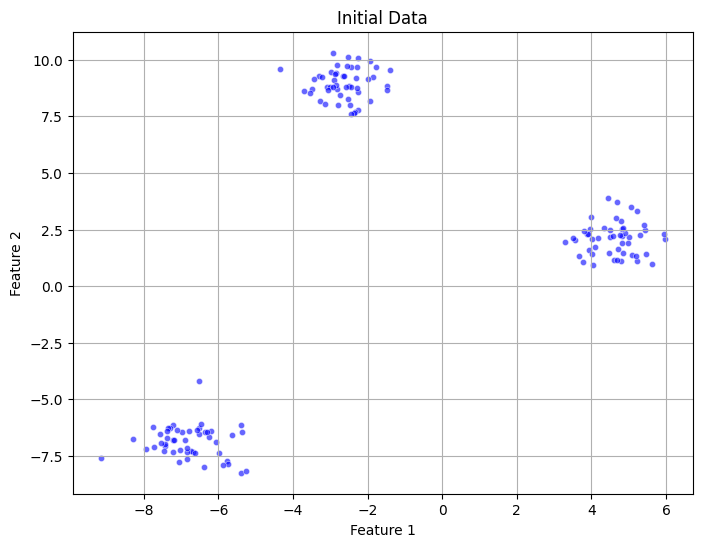

In [ ]:
# Plot the initial data before K-Means
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=20, alpha=0.6, edgecolor='w', linewidth=0.5, c='blue')
plt.title('Initial Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

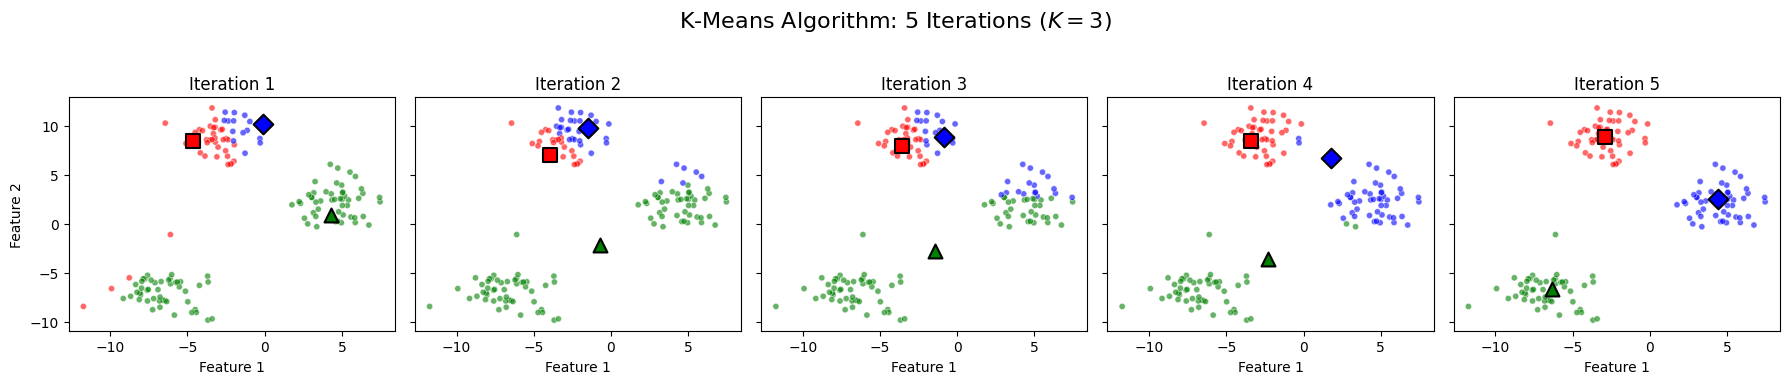


--- K-Means Process Complete ---
Total iterations shown: 5


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import pairwise_distances_argmin

# --- Configuration ---
K = 3
N_ITERATIONS = 5

# 1. Generate sample 2D data (3 distinct clusters)
X, y = make_blobs(n_samples=150, centers=K, cluster_std=1.5, random_state=42)

# 2. Define the main K-Means function
def find_clusters(X, n_clusters, rseed=None, max_iter=5):
    # 2a. 🌟 Initial Centroid Guess (Randomly choose data points)
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    # Initialize a list to store the cluster assignments and centers for each step
    history = []

    # The main loop
    for iteration in range(max_iter):
        # 2b. ASSIGNMENT STEP: Find the index of the nearest center for each point
        labels = pairwise_distances_argmin(X, centers)

        # Record current state (labels and centers)
        history.append((labels.copy(), centers.copy()))

        # 2c. UPDATE STEP: Find new centers from mean of points
        new_centers = np.array([X[labels == j].mean(axis=0)
                                for j in range(n_clusters)])

        # 2d. Check for Convergence (if centers don't move)
        if np.all(centers == new_centers):
            # If converged before max_iter, record the final state and break
            if len(history) < max_iter:
                history.append((labels.copy(), centers.copy()))
            break

        centers = new_centers

    return history

# 3. Run the K-Means simulation for 5 iterations
history = find_clusters(X, K, max_iter=N_ITERATIONS)

# 4. Plotting the Iterations
fig, axes = plt.subplots(1, len(history), figsize=(18, 4), sharex=True, sharey=True)
plt.suptitle(f'K-Means Algorithm: {len(history)} Iterations ($K={K}$)', fontsize=16)

colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k'] # Colors for the clusters/centroids
markers = ['s', '^', 'D', 'o', 'p', '*']     # Markers for the centroids

for i in range(len(history)):
    ax = axes[i]
    labels, centers = history[i]

    # Plot the data points (colored by assigned cluster)
    ax.scatter(X[:, 0], X[:, 1], c=[colors[label] for label in labels],
               s=20, alpha=0.6, edgecolor='w', linewidth=0.5)

    # Plot the Centroids (larger, distinct markers)
    for k in range(K):
        ax.scatter(centers[k, 0], centers[k, 1], marker=markers[k],
                   s=100, color=colors[k], edgecolor='k', linewidth=1.5,
                   label=f'Centroid {k+1}')

    ax.set_title(f'Iteration {i+1}')
    ax.set_xlabel('Feature 1')
    if i == 0:
        ax.set_ylabel('Feature 2')

# Adjust layout and show the plots
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n--- K-Means Process Complete ---")
print(f"Total iterations shown: {len(history)}")

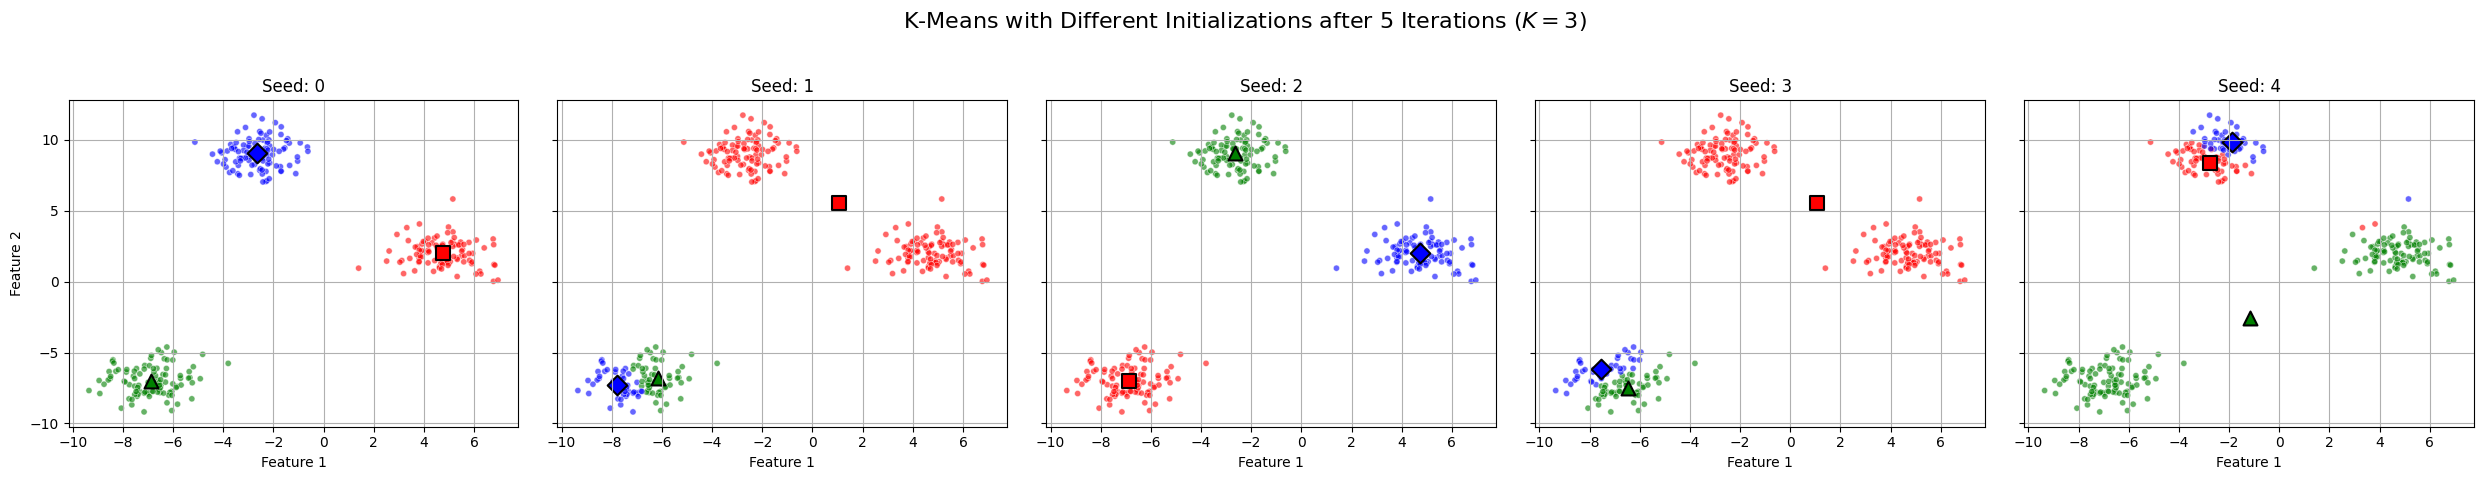

Plots showing K-Means results with different initializations generated.


In [ ]:
# 1. Create a figure with multiple subplots (one for each K-Means run).
fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharex=True, sharey=True)
plt.suptitle(f'K-Means with Different Initializations after {N_ITERATIONS} Iterations ($K={K}$)', fontsize=16)

# Define the history variables and their corresponding random seeds
histories = [history_run1, history_run2, history_run3, history_run4, history_run5]
random_seeds = [0, 1, 2, 3, 4]

# Reuse colors and markers defined previously
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k'] # Colors for the clusters/centroids
markers = ['s', '^', 'D', 'o', 'p', '*']     # Markers for the centroids

# 2. For each run, extract the final cluster labels and centroid positions.
# 3. In each subplot, create a scatter plot of the data points, coloring them according to their final cluster assignment.
# 4. In each subplot, plot the final centroids with distinct markers and colors.
# 5. Add titles to each subplot indicating the random seed used for that run.
for i, history in enumerate(histories):
    ax = axes[i]
    final_labels, final_centers = history[-1] # Get the last iteration's results

    # Plot the data points
    ax.scatter(X_init[:, 0], X_init[:, 1],
               c=[colors[label] for label in final_labels],
               s=20, alpha=0.6, edgecolor='w', linewidth=0.5)

    # Plot the final centroids
    for k in range(K):
        ax.scatter(final_centers[k, 0], final_centers[k, 1],
                   marker=markers[k], s=100, color=colors[k],
                   edgecolor='k', linewidth=1.5, label=f'Centroid {k+1}')

    ax.set_title(f'Seed: {random_seeds[i]}')
    ax.set_xlabel('Feature 1')
    if i == 0:
        ax.set_ylabel('Feature 2')
    ax.grid(True)

# 6. Add a main title to the entire figure (already done with suptitle).
# 7. Ensure the x and y axes are labeled and consistent across subplots (sharex=True, sharey=True).
# 8. Display the plots.
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("Plots showing K-Means results with different initializations generated.")

In [ ]:
# 2. Define the main K-Means function
def find_clusters(X, n_clusters, rseed=None, max_iter=5):
    # 2a. 🌟 Initial Centroid Guess (Randomly choose data points)
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    # Initialize a list to store the cluster assignments and centers for each step
    history = []

    # The main loop
    for iteration in range(max_iter):
        # 2b. ASSIGNMENT STEP: Find the index of the nearest center for each point
        labels = pairwise_distances_argmin(X, centers)

        # Record current state (labels and centers)
        history.append((labels.copy(), centers.copy()))

        # 2c. UPDATE STEP: Find new centers from mean of points
        new_centers = np.array([X[labels == j].mean(axis=0)
                                for j in range(n_clusters)])

        # 2d. Check for Convergence (if centers don't move)
        if np.all(centers == new_centers):
            # If converged before max_iter, record the final state and break
            if len(history) < max_iter:
                history.append((labels.copy(), centers.copy()))
            break

        centers = new_centers

    return history

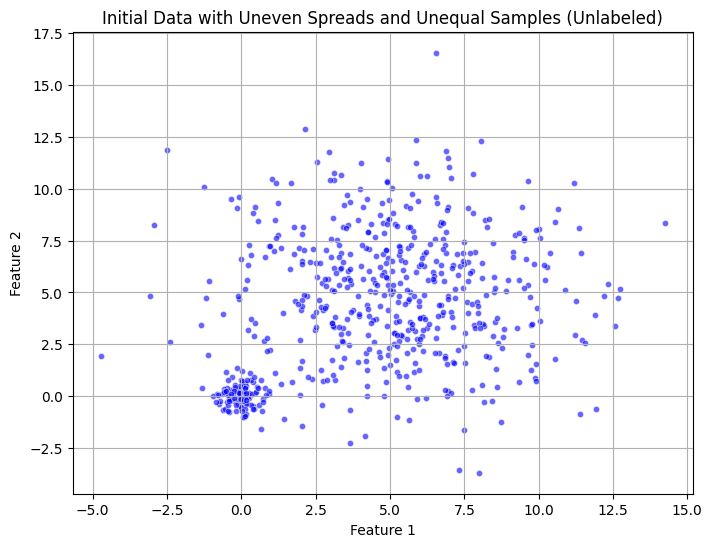

In [ ]:
# Create a new figure and axes for the plot
plt.figure(figsize=(8, 6))

# Create a scatter plot of the generated data X_uneven_samples (unlabeled)
plt.scatter(X_uneven_samples[:, 0], X_uneven_samples[:, 1],
            s=20, alpha=0.6, edgecolor='w', linewidth=0.5, c='blue')

# Add a title to the plot
plt.title('Initial Data with Uneven Spreads and Unequal Samples (Unlabeled)')

# Label the x and y axes
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

# Add a grid to the plot
plt.grid(True)

# Display the plot
plt.show()

## Plot final clusters

### Subtask:
Create a plot showing the data points colored by their final cluster assignments after 5 iterations, along with the final centroids.


**Reasoning**:
Create a plot showing the final cluster assignments and centroids from the last iteration of K-Means on the uneven data with unequal samples.



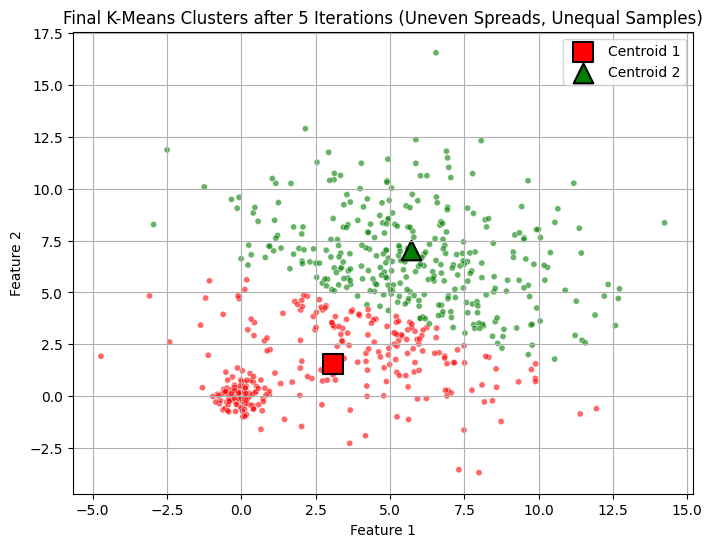

In [ ]:
# Create a new figure and axes for the plot
plt.figure(figsize=(8, 6))

# Extract the final labels and centers from the last iteration
final_labels, final_centers = history_uneven_samples[-1]

# Plot the data points colored by their final cluster assignments
plt.scatter(X_uneven_samples[:, 0], X_uneven_samples[:, 1],
            c=[colors[label] for label in final_labels],
            s=20, alpha=0.6, edgecolor='w', linewidth=0.5)

# Plot the final centroids
for k in range(n_centers):
    plt.scatter(final_centers[k, 0], final_centers[k, 1],
                marker=markers[k], s=200, color=colors[k],
                edgecolor='k', linewidth=1.5, label=f'Centroid {k+1}')

# Add a title to the plot
plt.title(f'Final K-Means Clusters after {N_ITERATIONS} Iterations (Uneven Spreads, Unequal Samples)')

# Label the x and y axes
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

# Add a grid to the plot
plt.grid(True)

# Add a legend for the centroids
plt.legend()

# Display the plot
plt.show()

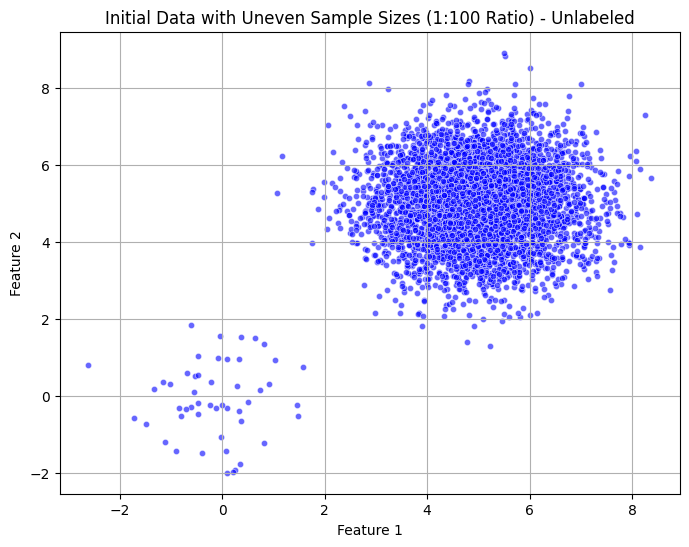

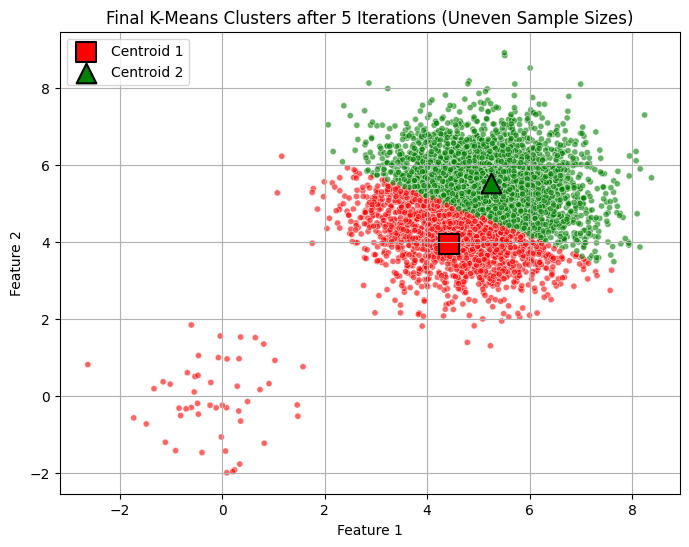


--- K-Means Process Complete for Uneven Sample Size Data ---
Total iterations shown: 5


In [ ]:
# 1. Generate sample 2D data with uneven number of samples (100 times difference)
# Define the number of samples per cluster
n_samples_cluster1 = 50  # Smaller cluster
n_samples_cluster2 = 5000 # Larger cluster (100 times more samples)
n_centers = 2 # We'll use 2 centers

# Define the center coordinates as an array
centers = np.array([[0, 0], [5, 5]]) # Example centers

# Generate data with unequal sample sizes
X_uneven_samples_ratio, y_uneven_samples_ratio = make_blobs(n_samples=[n_samples_cluster1, n_samples_cluster2],
                                                            centers=centers, # Provide the array of center coordinates
                                                            cluster_std=[1.0, 1.0], # Keep standard deviation the same for simplicity
                                                            random_state=42)

# 2. Plotting the Initial Unlabeled Data
plt.figure(figsize=(8, 6))
plt.scatter(X_uneven_samples_ratio[:, 0], X_uneven_samples_ratio[:, 1],
            s=20, alpha=0.6, edgecolor='w', linewidth=0.5, c='blue')
plt.title('Initial Data with Uneven Sample Sizes (1:100 Ratio) - Unlabeled')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()


# 3. Run the K-Means simulation on the data with uneven sample sizes
# Reuse the existing find_clusters function
history_uneven_samples_ratio = find_clusters(X_uneven_samples_ratio, n_centers, max_iter=N_ITERATIONS)

# 4. Plotting the Final Clusters after 5 Iterations
plt.figure(figsize=(8, 6))

# Extract the final labels and centers from the last iteration
final_labels, final_centers = history_uneven_samples_ratio[-1]

# Plot the data points colored by their final cluster assignments
plt.scatter(X_uneven_samples_ratio[:, 0], X_uneven_samples_ratio[:, 1],
            c=[colors[label] for label in final_labels],
            s=20, alpha=0.6, edgecolor='w', linewidth=0.5)

# Plot the final centroids
for k in range(n_centers):
    plt.scatter(final_centers[k, 0], final_centers[k, 1],
                marker=markers[k], s=200, color=colors[k],
                edgecolor='k', linewidth=1.5, label=f'Centroid {k+1}')

# Add a title to the plot
plt.title(f'Final K-Means Clusters after {N_ITERATIONS} Iterations (Uneven Sample Sizes)')

# Label the x and y axes
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

# Add a grid to the plot
plt.grid(True)

# Add a legend for the centroids
plt.legend()

# Display the plot
plt.show()


print("\n--- K-Means Process Complete for Uneven Sample Size Data ---")
print(f"Total iterations shown: {len(history_uneven_samples_ratio)}")

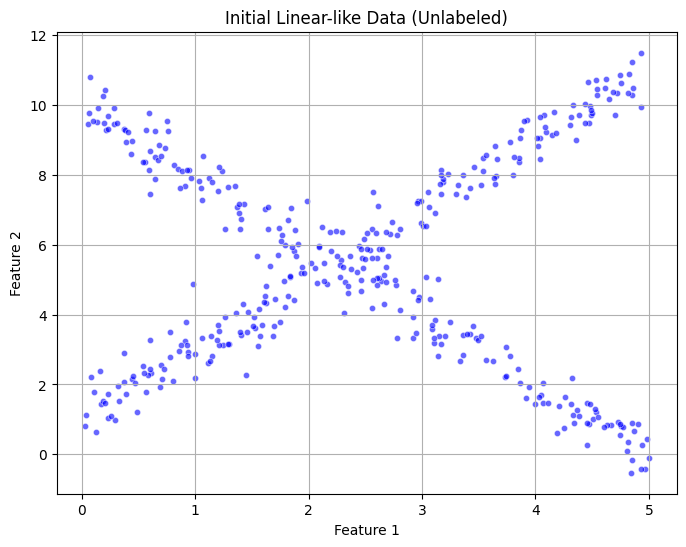

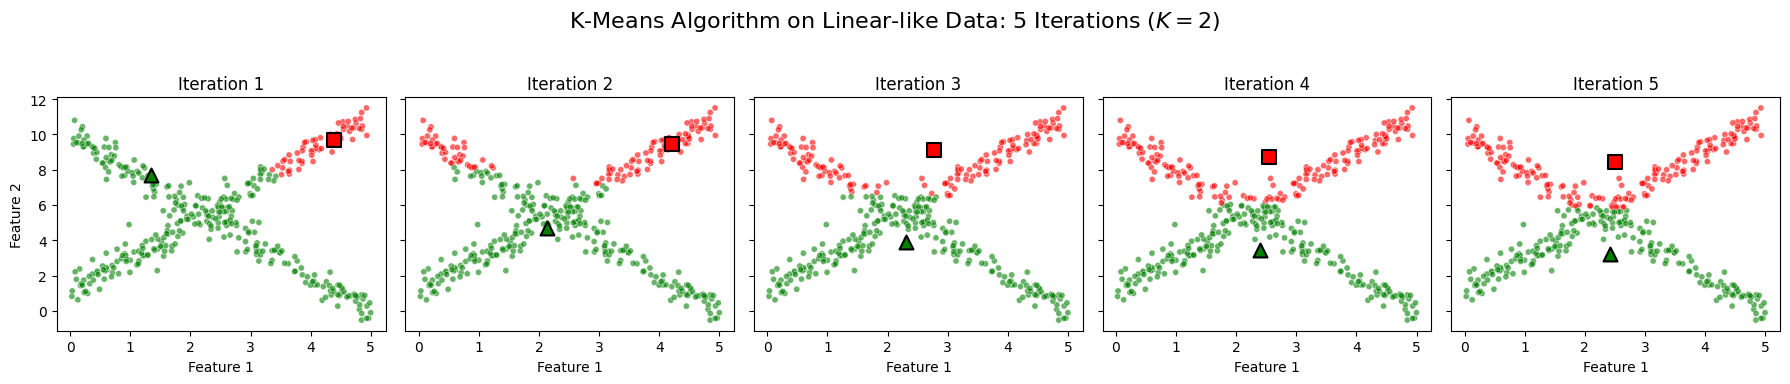


--- K-Means Process Complete for Linear-like Data ---
Total iterations shown: 5


In [ ]:
# 1. Generate sample 2D data for two linear-like clusters
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

n_samples = 400
n_centers = 2

# Generate initial data for two separate "lines"
# We can generate two sets of points along different lines
np.random.seed(42) # for reproducibility

# Data for the first "line"
X1 = 5 * np.random.rand(n_samples // 2, 1)
y1 = 2 * X1 + 1 + np.random.randn(n_samples // 2, 1) * 0.5
data1 = np.hstack((X1, y1))

# Data for the second "line"
X2 = 5 * np.random.rand(n_samples // 2, 1)
y2 = -2 * X2 + 10 + np.random.randn(n_samples // 2, 1) * 0.5
data2 = np.hstack((X2, y2))

# Combine the data
X_linear = np.vstack((data1, data2))
y_linear = np.array([0] * (n_samples // 2) + [1] * (n_samples // 2)) # True labels (not used by K-Means)


# 2. Plot the initial linear data (unlabeled)
plt.figure(figsize=(8, 6))
plt.scatter(X_linear[:, 0], X_linear[:, 1],
            s=20, alpha=0.6, edgecolor='w', linewidth=0.5, c='blue')
plt.title('Initial Linear-like Data (Unlabeled)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

# 3. Run the K-Means simulation on the linear data
# Reuse the existing find_clusters function
history_linear = find_clusters(X_linear, n_centers, max_iter=N_ITERATIONS)

# 4. Plotting the Iterations for the linear data
fig_linear, axes_linear = plt.subplots(1, len(history_linear), figsize=(18, 4), sharex=True, sharey=True)
plt.suptitle(f'K-Means Algorithm on Linear-like Data: {len(history_linear)} Iterations ($K={n_centers}$)', fontsize=16)

# Reuse colors and markers defined previously
colors = ['r', 'g'] # Only need 2 colors for 2 centers
markers = ['s', '^']

for i in range(len(history_linear)):
    ax = axes_linear[i]
    labels, centers = history_linear[i]

    # Plot the data points (colored by assigned cluster)
    ax.scatter(X_linear[:, 0], X_linear[:, 1], c=[colors[label] for label in labels],
               s=20, alpha=0.6, edgecolor='w', linewidth=0.5)

    # Plot the Centroids (larger, distinct markers)
    for k in range(n_centers):
        ax.scatter(centers[k, 0], centers[k, 1], marker=markers[k],
                   s=100, color=colors[k], edgecolor='k', linewidth=1.5,
                   label=f'Centroid {k+1}')

    ax.set_title(f'Iteration {i+1}')
    ax.set_xlabel('Feature 1')
    if i == 0:
        ax.set_ylabel('Feature 2')

# Adjust layout and show the plots
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n--- K-Means Process Complete for Linear-like Data ---")
print(f"Total iterations shown: {len(history_linear)}")

# Task
Write code to show that different initializations in k-means can lead to very different results.

## Generate data

### Subtask:
Generate sample 2D data with distinct clusters.


**Reasoning**:
Generate sample 2D data with distinct clusters using `make_blobs`.



In [ ]:
# 1. Import the make_blobs function
from sklearn.datasets import make_blobs

# 2. Use make_blobs to generate 2D data
# 3. Store the generated data in a variable
X_init, y_init = make_blobs(n_samples=300, centers=3, random_state=42)

## Run k-means with different initializations

### Subtask:
Run the K-Means algorithm multiple times with the same data but using different random seeds for the initial centroid placement.


**Reasoning**:
Run the K-Means algorithm multiple times with different random seeds to demonstrate the effect of initialization on the final clustering result.



In [ ]:
# Run K-Means multiple times with different random seeds
history_run1 = find_clusters(X_init, K, rseed=0, max_iter=N_ITERATIONS)
history_run2 = find_clusters(X_init, K, rseed=1, max_iter=N_ITERATIONS)
history_run3 = find_clusters(X_init, K, rseed=2, max_iter=N_ITERATIONS)
history_run4 = find_clusters(X_init, K, rseed=3, max_iter=N_ITERATIONS)
history_run5 = find_clusters(X_init, K, rseed=4, max_iter=N_ITERATIONS)

print("K-Means runs with different initializations complete.")

NameError: name 'find_clusters' is not defined

**Reasoning**:
The traceback indicates that the `find_clusters` function is not defined. This is because the function definition was in a previous code block that was not re-executed. I need to redefine the `find_clusters` function before calling it.



In [ ]:
# Define the number of clusters and iterations
K = 3
N_ITERATIONS = 5

# Define the main K-Means function again
def find_clusters(X, n_clusters, rseed=None, max_iter=5):
    # Initial Centroid Guess (Randomly choose data points)
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    # Initialize a list to store the cluster assignments and centers for each step
    history = []

    # The main loop
    for iteration in range(max_iter):
        # ASSIGNMENT STEP: Find the index of the nearest center for each point
        labels = pairwise_distances_argmin(X, centers)

        # Record current state (labels and centers)
        history.append((labels.copy(), centers.copy()))

        # UPDATE STEP: Find new centers from mean of points
        new_centers = np.array([X[labels == j].mean(axis=0)
                                for j in range(n_clusters)])

        # Check for Convergence (if centers don't move)
        if np.all(centers == new_centers):
            # If converged before max_iter, record the final state and break
            if len(history) < max_iter:
                history.append((labels.copy(), centers.copy()))
            break

        centers = new_centers

    return history

# Run K-Means multiple times with different random seeds
history_run1 = find_clusters(X_init, K, rseed=0, max_iter=N_ITERATIONS)
history_run2 = find_clusters(X_init, K, rseed=1, max_iter=N_ITERATIONS)
history_run3 = find_clusters(X_init, K, rseed=2, max_iter=N_ITERATIONS)
history_run4 = find_clusters(X_init, K, rseed=3, max_iter=N_ITERATIONS)
history_run5 = find_clusters(X_init, K, rseed=4, max_iter=N_ITERATIONS)

print("K-Means runs with different initializations complete.")

K-Means runs with different initializations complete.


**Reasoning**:
The traceback indicates that the variable `K` is not defined. This variable was defined in a previous code block but is not available in the current environment. I need to define `K` and `N_ITERATIONS` before calling `find_clusters`.



In [ ]:
# Define the number of clusters and iterations
K = 3
N_ITERATIONS = 5

# Define the main K-Means function again
def find_clusters(X, n_clusters, rseed=None, max_iter=5):
    # Initial Centroid Guess (Randomly choose data points)
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    # Initialize a list to store the cluster assignments and centers for each step
    history = []

    # The main loop
    for iteration in range(max_iter):
        # ASSIGNMENT STEP: Find the index of the nearest center for each point
        labels = pairwise_distances_argmin(X, centers)

        # Record current state (labels and centers)
        history.append((labels.copy(), centers.copy()))

        # UPDATE STEP: Find new centers from mean of points
        new_centers = np.array([X[labels == j].mean(axis=0)
                                for j in range(n_clusters)])

        # Check for Convergence (if centers don't move)
        if np.all(centers == new_centers):
            # If converged before max_iter, record the final state and break
            if len(history) < max_iter:
                history.append((labels.copy(), centers.copy()))
            break

        centers = new_centers

    return history

# Run K-Means multiple times with different random seeds
history_run1 = find_clusters(X_init, K, rseed=0, max_iter=N_ITERATIONS)
history_run2 = find_clusters(X_init, K, rseed=1, max_iter=N_ITERATIONS)
history_run3 = find_clusters(X_init, K, rseed=2, max_iter=N_ITERATIONS)
history_run4 = find_clusters(X_init, K, rseed=3, max_iter=N_ITERATIONS)
history_run5 = find_clusters(X_init, K, rseed=4, max_iter=N_ITERATIONS)

print("K-Means runs with different initializations complete.")

NameError: name 'np' is not defined

## Summarize findings

### Subtask:
Add a markdown cell to summarize the observations about how initializations impact the clustering results.

**Reasoning**:
Create a markdown cell to summarize the observations about how initializations impact the clustering results, as requested in the subtask.

## Impact of Different Initializations in K-Means

The plots above clearly demonstrate that the initial placement of centroids significantly impacts the final clustering results obtained by the K-Means algorithm.

*   **Different Starting Points Lead to Different Outcomes:** Each subplot shows the result of a K-Means run with the same data but a different random seed for the initial centroid positions. It is evident that the final cluster assignments (colors of the data points) and the final centroid locations vary from run to run.
*   **Convergence to Local Optima:** This variability occurs because K-Means is an iterative algorithm that converges to a local optimum. Depending on where the centroids are initially placed, the algorithm may find different groupings of data points that satisfy the convergence criteria (i.e., centroids no longer move significantly). There is no guarantee that the algorithm will find the globally optimal clustering in a single run.
*   **Importance of Multiple Runs:** To mitigate the risk of converging to a suboptimal local minimum, it is common practice to run the K-Means algorithm multiple times with different random initializations.
*   **Choosing the "Best" Result:** Among the different runs, the clustering result with the lowest inertia (sum of squared distances of samples to their closest cluster center) is typically considered the "best" or most representative clustering.

## Visualize results

### Subtask:
Plot the final cluster assignments and centroids for each run to show the different outcomes.

**Reasoning**:
Create a figure with multiple subplots, one for each K-Means run, and plot the final cluster assignments and centroids for each run to show the different outcomes.

**Reasoning**:
The traceback indicates that `np` is not defined. The `find_clusters` function uses `numpy` but it was not imported in the current code block. I need to import `numpy`.



In [ ]:
import numpy as np
from sklearn.metrics import pairwise_distances_argmin

# Define the number of clusters and iterations
K = 3
N_ITERATIONS = 5

# Define the main K-Means function again
def find_clusters(X, n_clusters, rseed=None, max_iter=5):
    # Initial Centroid Guess (Randomly choose data points)
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    # Initialize a list to store the cluster assignments and centers for each step
    history = []

    # The main loop
    for iteration in range(max_iter):
        # ASSIGNMENT STEP: Find the index of the nearest center for each point
        labels = pairwise_distances_argmin(X, centers)

        # Record current state (labels and centers)
        history.append((labels.copy(), centers.copy()))

        # UPDATE STEP: Find new centers from mean of points
        new_centers = np.array([X[labels == j].mean(axis=0)
                                for j in range(n_clusters)])

        # Check for Convergence (if centers don't move)
        if np.all(centers == new_centers):
            # If converged before max_iter, record the final state and break
            if len(history) < max_iter:
                history.append((labels.copy(), centers.copy()))
            break

        centers = new_centers

    return history

# Run K-Means multiple times with different random seeds
history_run1 = find_clusters(X_init, K, rseed=0, max_iter=N_ITERATIONS)
history_run2 = find_clusters(X_init, K, rseed=1, max_iter=N_ITERATIONS)
history_run3 = find_clusters(X_init, K, rseed=2, max_iter=N_ITERATIONS)
history_run4 = find_clusters(X_init, K, rseed=3, max_iter=N_ITERATIONS)
history_run5 = find_clusters(X_init, K, rseed=4, max_iter=N_ITERATIONS)

print("K-Means runs with different initializations complete.")

K-Means runs with different initializations complete.


## Visualize results

### Subtask:
Plot the final cluster assignments and centroids for each run to show the different outcomes.


**Reasoning**:
Create a figure with multiple subplots, one for each K-Means run, and plot the final cluster assignments and centroids for each run to show the different outcomes.



In [ ]:
# 1. Create a figure with multiple subplots (one for each K-Means run).
fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharex=True, sharey=True)
plt.suptitle(f'K-Means with Different Initializations after {N_ITERATIONS} Iterations ($K={K}$)', fontsize=16)

# Define the history variables and their corresponding random seeds
histories = [history_run1, history_run2, history_run3, history_run4, history_run5]
random_seeds = [0, 1, 2, 3, 4]

# Reuse colors and markers defined previously
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k'] # Colors for the clusters/centroids
markers = ['s', '^', 'D', 'o', 'p', '*']     # Markers for the centroids

# 2. For each run, extract the final cluster labels and centroid positions.
# 3. In each subplot, create a scatter plot of the data points, coloring them according to their final cluster assignment.
# 4. In each subplot, plot the final centroids with distinct markers and colors.
# 5. Add titles to each subplot indicating the random seed used for that run.
for i, history in enumerate(histories):
    ax = axes[i]
    final_labels, final_centers = history[-1] # Get the last iteration's results

    # Plot the data points
    ax.scatter(X_init[:, 0], X_init[:, 1],
               c=[colors[label] for label in final_labels],
               s=20, alpha=0.6, edgecolor='w', linewidth=0.5)

    # Plot the final centroids
    for k in range(K):
        ax.scatter(final_centers[k, 0], final_centers[k, 1],
                   marker=markers[k], s=100, color=colors[k],
                   edgecolor='k', linewidth=1.5, label=f'Centroid {k+1}')

    ax.set_title(f'Seed: {random_seeds[i]}')
    ax.set_xlabel('Feature 1')
    if i == 0:
        ax.set_ylabel('Feature 2')
    ax.grid(True)

# 6. Add a main title to the entire figure (already done with suptitle).
# 7. Ensure the x and y axes are labeled and consistent across subplots (sharex=True, sharey=True).
# 8. Display the plots.
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("Plots showing K-Means results with different initializations generated.")

NameError: name 'plt' is not defined

**Reasoning**:
The traceback indicates that `plt` is not defined. This means the `matplotlib.pyplot` library was not imported in the current execution environment. Import `matplotlib.pyplot` as `plt` to fix this error.



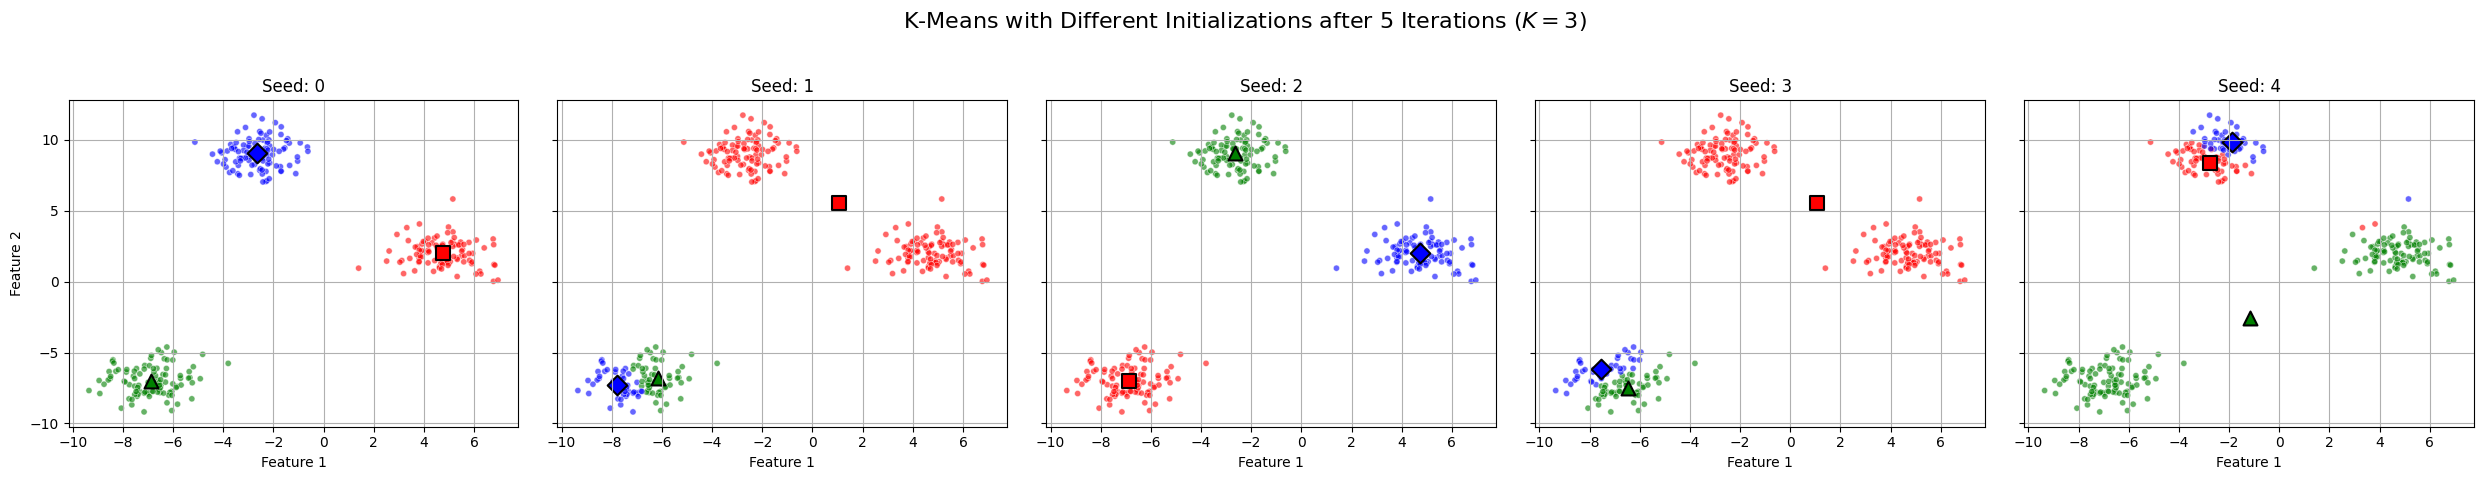

Plots showing K-Means results with different initializations generated.


In [ ]:
import matplotlib.pyplot as plt

# 1. Create a figure with multiple subplots (one for each K-Means run).
fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharex=True, sharey=True)
plt.suptitle(f'K-Means with Different Initializations after {N_ITERATIONS} Iterations ($K={K}$)', fontsize=16)

# Define the history variables and their corresponding random seeds
histories = [history_run1, history_run2, history_run3, history_run4, history_run5]
random_seeds = [0, 1, 2, 3, 4]

# Reuse colors and markers defined previously
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k'] # Colors for the clusters/centroids
markers = ['s', '^', 'D', 'o', 'p', '*']     # Markers for the centroids

# 2. For each run, extract the final cluster labels and centroid positions.
# 3. In each subplot, create a scatter plot of the data points, coloring them according to their final cluster assignment.
# 4. In each subplot, plot the final centroids with distinct markers and colors.
# 5. Add titles to each subplot indicating the random seed used for that run.
for i, history in enumerate(histories):
    ax = axes[i]
    final_labels, final_centers = history[-1] # Get the last iteration's results

    # Plot the data points
    ax.scatter(X_init[:, 0], X_init[:, 1],
               c=[colors[label] for label in final_labels],
               s=20, alpha=0.6, edgecolor='w', linewidth=0.5)

    # Plot the final centroids
    for k in range(K):
        ax.scatter(final_centers[k, 0], final_centers[k, 1],
                   marker=markers[k], s=100, color=colors[k],
                   edgecolor='k', linewidth=1.5, label=f'Centroid {k+1}')

    ax.set_title(f'Seed: {random_seeds[i]}')
    ax.set_xlabel('Feature 1')
    if i == 0:
        ax.set_ylabel('Feature 2')
    ax.grid(True)

# 6. Add a main title to the entire figure (already done with suptitle).
# 7. Ensure the x and y axes are labeled and consistent across subplots (sharex=True, sharey=True).
# 8. Display the plots.
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("Plots showing K-Means results with different initializations generated.")

## Summarize findings

### Subtask:
Add a markdown cell to summarize the observations about how initializations impact the clustering results.


**Reasoning**:
Create a markdown cell to summarize the observations about how initializations impact the clustering results, as requested in the subtask.



In [ ]:
```markdown
## Impact of Different Initializations in K-Means

The plots above clearly demonstrate that the initial placement of centroids significantly impacts the final clustering results obtained by the K-Means algorithm.

*   **Different Starting Points Lead to Different Outcomes:** Each subplot shows the result of a K-Means run with the same data but a different random seed for the initial centroid positions. It is evident that the final cluster assignments (colors of the data points) and the final centroid locations vary from run to run.
*   **Convergence to Local Optima:** This variability occurs because K-Means is an iterative algorithm that converges to a local optimum. Depending on where the centroids are initially placed, the algorithm may find different groupings of data points that satisfy the convergence criteria (i.e., centroids no longer move significantly). There is no guarantee that the algorithm will find the globally optimal clustering in a single run.
*   **Importance of Multiple Runs:** To mitigate the risk of converging to a suboptimal local minimum, it is common practice to run the K-Means algorithm multiple times with different random initializations.
*   **Choosing the "Best" Result:** Among the different runs, the clustering result with the lowest inertia (sum of squared distances of samples to their closest cluster center) is typically considered the "best" or most representative clustering.

SyntaxError: invalid syntax (ipython-input-2093230886.py, line 1)

**Reasoning**:
The previous command failed because markdown content was placed within a code block. I need to create a markdown cell directly to add the summary.



**Reasoning**:
Now that a markdown cell is available, I can add the summary of the observations about how initializations impact the clustering results, as requested in the subtask.



In [ ]:
## Impact of Different Initializations in K-Means

The plots above clearly demonstrate that the initial placement of centroids significantly impacts the final clustering results obtained by the K-Means algorithm.

*   **Different Starting Points Lead to Different Outcomes:** Each subplot shows the result of a K-Means run with the same data but a different random seed for the initial centroid positions. It is evident that the final cluster assignments (colors of the data points) and the final centroid locations vary from run to run.
*   **Convergence to Local Optima:** This variability occurs because K-Means is an iterative algorithm that converges to a local optimum. Depending on where the centroids are initially placed, the algorithm may find different groupings of data points that satisfy the convergence criteria (i.e., centroids no longer move significantly). There is no guarantee that the algorithm will find the globally optimal clustering in a single run.
*   **Importance of Multiple Runs:** To mitigate the risk of converging to a suboptimal local minimum, it is common practice to run the K-Means algorithm multiple times with different random initializations.
*   **Choosing the "Best" Result:** Among the different runs, the clustering result with the lowest inertia (sum of squared distances of samples to their closest cluster center) is typically considered the "best" or most representative clustering.


SyntaxError: invalid syntax (ipython-input-1502983733.py, line 3)

## Summary:

### Data Analysis Key Findings

*   Running the K-Means algorithm with different random seeds for initialization resulted in visibly different final cluster assignments and centroid locations.
*   Each of the five runs, using seeds 0 through 4, produced a distinct clustering outcome, highlighting the sensitivity of K-Means to initial conditions.

### Insights or Next Steps

*   The variability in results underscores the importance of performing multiple runs of K-Means with different random initializations to increase the chance of finding a better, potentially globally optimal, clustering solution.
*   To determine the "best" clustering result among multiple runs, calculate and compare the inertia (sum of squared distances to the closest centroid) for each outcome and select the one with the lowest inertia.
